# 01. 에너지 소비 모델 분석

`data/ev_energy_consumption.csv`로 전기차 100km당 에너지 소비량을 분석하고,
전처리 방법 4가지(Baseline / Scaling / Feature Engineering / FE + Scaling)를
동일한 Train/Test 분할에서 비교한다.

- Target: `energy_consumption_kwhper100km` (연속값 → 회귀)
- 평가: R², MAE, RMSE
- 파생변수 생성은 `ev_logistics.features.create_ev_features`를 그대로 사용한다.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from ev_logistics.config import BASE_FEATURES, ENERGY_CSV, RANDOM_STATE, TARGET
from ev_logistics.features import create_ev_features

## 1. 데이터 로드와 파생변수

In [2]:
df = pd.read_csv(ENERGY_CSV)[BASE_FEATURES + [TARGET]].copy()
print(f'행/열: {df.shape[0]:,} x {df.shape[1]}')
print(f'결측 {int(df.isna().sum().sum())}개 · 중복 {int(df.duplicated().sum())}개')
df = df.dropna().reset_index(drop=True)

df_fe = create_ev_features(df)
engineered_features = [c for c in df_fe.columns if c != TARGET]
print(f'기본 {len(BASE_FEATURES)}개 → 파생 포함 {len(engineered_features)}개')
df_fe.head()

행/열: 8,000 x 10
결측 0개 · 중복 0개
기본 9개 → 파생 포함 16개


,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km,speed_squared,ambient_temp_deviation,battery_temp_deviation,tire_pressure_deviation,payload_grade,hvac_temp_interaction,speed_driving_interaction
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357,3745.44,34.8,6.0,0.02,-1674.465,119.364,42.0444
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554,15525.16,35.0,12.2,0.39,-1683.640,81.900,51.4598
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004,10100.25,11.4,11.2,0.18,-99.632,3.192,28.1400
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539,7378.81,33.5,9.6,0.28,2486.407,153.765,52.9144
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883,1383.84,13.7,8.9,0.05,1921.192,67.130,27.5280


## 2. 타깃 분포와 상관

,corr_with_target
ambient_temp_C,-0.155499
tire_pressure_bar,-0.095066
battery_temp_C,-0.086873
battery_temp_deviation,-0.013635
tire_pressure_deviation,0.001177
trip_distance_km,0.171982
ambient_temp_deviation,0.198043
driving_style_index,0.258434
hvac_temp_interaction,0.351334
hvac_power_kw,0.369619


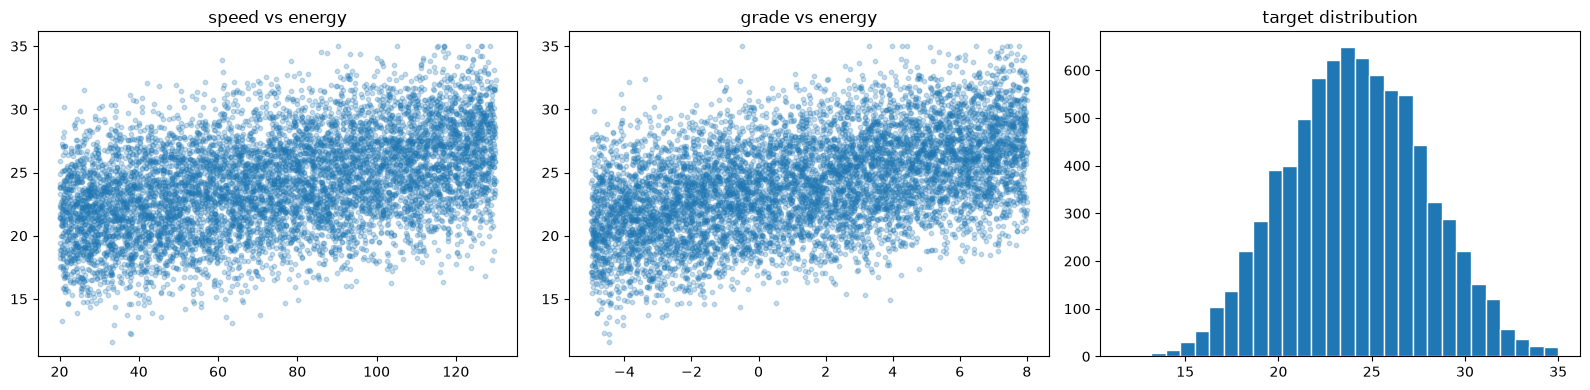

In [3]:
corr = df_fe[engineered_features + [TARGET]].corr(numeric_only=True)[TARGET].sort_values()
display(corr.to_frame('corr_with_target'))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].scatter(df['speed_kmh'], df[TARGET], alpha=.25, s=10); ax[0].set_title('speed vs energy')
ax[1].scatter(df['road_grade_pct'], df[TARGET], alpha=.25, s=10); ax[1].set_title('grade vs energy')
ax[2].hist(df[TARGET], bins=30, edgecolor='white'); ax[2].set_title('target distribution')
plt.tight_layout(); plt.show()

## 3. 전처리 4종 x 모델 4종 비교

`StandardScaler`는 각 실험의 학습 데이터에만 `fit`하고 테스트에는 `transform`만 적용해
데이터 누수를 막는다.

In [4]:
X_base = df[BASE_FEATURES]
X_fe = df_fe[engineered_features]
y = df[TARGET]
Xb_tr, Xb_te, y_tr, y_te = train_test_split(X_base, y, test_size=.2, random_state=RANDOM_STATE)
Xf_tr, Xf_te = X_fe.loc[Xb_tr.index], X_fe.loc[Xb_te.index]

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'SVR': SVR(C=10, epsilon=.1, kernel='rbf'),
}
experiments = {
    'A. Baseline': (Xb_tr, Xb_te, False),
    'B. Baseline + Scaling': (Xb_tr, Xb_te, True),
    'C. Feature Engineering': (Xf_tr, Xf_te, False),
    'D. FE + Scaling': (Xf_tr, Xf_te, True),
}

rows = []
for exp, (tr, te, scale) in experiments.items():
    for name, est in models.items():
        model = make_pipeline(StandardScaler(), est) if scale else est
        model.fit(tr, y_tr)
        pred = model.predict(te)
        rows.append({
            'experiment': exp, 'model': name,
            'R2': r2_score(y_te, pred),
            'MAE': mean_absolute_error(y_te, pred),
            'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        })
results = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
results

,experiment,model,R2,MAE,RMSE
0,D. FE + Scaling,Linear Regression,0.941720,0.704513,0.887474
1,C. Feature Engineering,Linear Regression,0.941720,0.704513,0.887474
2,B. Baseline + Scaling,SVR,0.939416,0.723187,0.904847
3,D. FE + Scaling,SVR,0.937561,0.735062,0.918596
4,B. Baseline + Scaling,Gradient Boosting,0.934634,0.750800,0.939878
5,A. Baseline,Gradient Boosting,0.934599,0.750975,0.940131
6,D. FE + Scaling,Gradient Boosting,0.930056,0.766250,0.972235
7,C. Feature Engineering,Gradient Boosting,0.930052,0.766316,0.972267
8,A. Baseline,Linear Regression,0.924621,0.810735,1.009304
9,B. Baseline + Scaling,Linear Regression,0.924621,0.810735,1.009304


In [5]:
best = results.iloc[0]
baseline_rmse = results.loc[results['experiment'].eq('A. Baseline'), 'RMSE'].min()
improvement = (baseline_rmse - best['RMSE']) / baseline_rmse * 100
print(f"선정: {best['experiment']} / {best['model']}  RMSE={best['RMSE']:.3f}  R2={best['R2']:.4f}")
print(f'Baseline 대비 RMSE {improvement:.2f}% 개선')

선정: D. FE + Scaling / Linear Regression  RMSE=0.887  R2=0.9417
Baseline 대비 RMSE 5.60% 개선


## 4. 서비스에서 쓰는 모델

서비스(`app/app.py`, `scripts/`)는 위 비교에서 가장 좋은 **FE + Scaling / LinearRegression**
조합을 `ev_logistics.model.train_energy_model`로 학습해 `models/energy_model.joblib`에 저장하고
재사용한다. 아래로 동일 결과를 확인한다.

In [6]:
from ev_logistics.model import train_energy_model
bundle = train_energy_model(save=False)
bundle['metrics']

{'R2': 0.9417201218050536,
 'MAE': 0.7045131976291655,
 'RMSE': 0.8874742526957434}